In [21]:
import torch
import numpy as np
import random
import scanpy as sc
from sklearn.decomposition import PCA
import os
import pandas as pd

from utils import load_data
from model import Model, Trainer


In [22]:
import sys
from opt import get_args

preset = {
    'name': 'CHD',
    'slice': 'D14',
    'device': 'cuda:0',
    'image_type': 'ViT',
    'image_emb_type': 'vit_patch_cls',
}

args = get_args(preset=preset)

In [23]:
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

torch.cuda.manual_seed(args.seed)          
os.environ['PYTHONHASHSEED'] = str(args.seed)  

In [24]:
adata, A_P, A_I  = load_data(args)
X = torch.FloatTensor(adata.obsm["X_pca"])

/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/scanpy/preprocessing/_deprecated/highly_variable_genes.py:131: UserWarning: If you pass `n_top_genes`, all cutoffs are ignored.
  warnings.warn(msg, UserWarning)


------Calculating spatial graph...
The graph contains 5901 edges, 1967 cells.
3.0000 neighbors per cell on average.
------Calculating spatial graph...


/data/guoyin/ST_HosImage/SUL/CL/a_st-Xprop/adj.py:43: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 6846 edges, 1967 cells.
3.4804 neighbors per cell on average.


In [27]:

model = Model(A_P, A_I, args, n_nodes=X.shape[0], input_dim=X.shape[1]).to(args.device)
trainer = Trainer(model=model, device=args.device)
ari_df = trainer.fit(adata, adata.obs["ground_truth"], A_P, A_I, args)

PreTraining...


  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [00:04<00:00, 46.97it/s]
/data/guoyin/ST_HosImage/SUL/CL/a_st-Xprop/training.py:177: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_

Pretrain model saved.


100%|██████████| 1001/1001 [00:26<00:00, 37.32it/s]


Evaluating n_clusters = 6
fitting ...
  |======================================================================| 100%


In [28]:
ari_df

,kmeans,mclust
0,0.610735,0.740794


In [31]:
adata

AnnData object with n_obs × n_vars = 1967 × 3000
    obs: 'ident', 'clusters', 'celltypes', 'region', 'ground_truth', 'kmeans', 'mclust'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'Spatial_Net', 'ground_truth_colors', 'mclust_colors'
    obsm: 'spatial', 'X_pca', 'image_spatial', 'st-Xprop'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

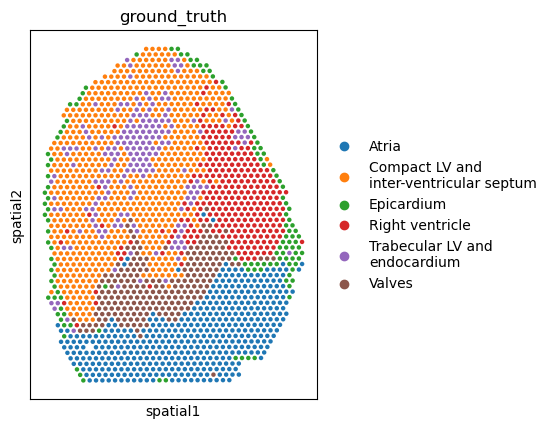

In [29]:
sc.pl.spatial(adata,  color=['ground_truth'],spot_size=150,size=1.3,color_map='viridis', show=True) 

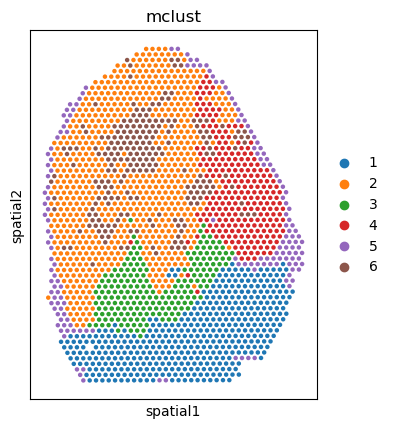

In [30]:
sc.pl.spatial(adata, color=[f'mclust'], spot_size=150, size=1.3, color_map='viridis')